## Imports

In [59]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

from neuro_fuzzy_toolbox import h_ANFIS, Hybrid_learning_algorithm, SONFIS, EarlyStopping, get_measures, Gaussian_MF

In [60]:
import numpy as np

In [61]:
from sklearn.preprocessing import MinMaxScaler

# Surface (10k)

## Data

In [62]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

e = np.random.normal(0,0.1,10000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)

In [63]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [64]:
train_loader = data.DataLoader(
    data.TensorDataset(
        torch.from_numpy(scaled_train), 
        torch.from_numpy(Y)), 
    batch_size = 64, 
    shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

In [65]:
x_train.dtype

torch.float64

## Model & Training

### ANFIS

In [66]:
model = h_ANFIS(
    input_size = 2,
    num_mfs = 1,
    outputs = 1,
    rule_reduced= True,
    dtype= torch.float64
)

In [67]:
model.init_premises(x_train)

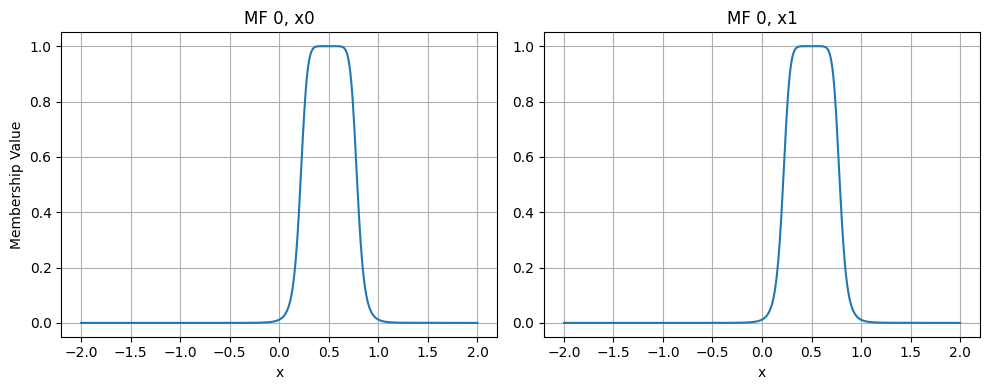

In [68]:
model.plot_premises()

In [69]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.287053,4.0,0.50037,0.286779,4.0,0.499042


### Hybrid Learning Algorithm

In [70]:
loss_fn = nn.functional.mse_loss

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [71]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [72]:
Ngrow = 400
dGrow = 0.8
Nsplit = 200
eSplit = 0.5
Nvanish = 60
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=8)
last_training_iteration = True

In [73]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [74]:
%time sonfis(model, train_loader, verbose=True)

Iteration:  0/40 - loss: 3.893267 - validation loss: 3.661153
 -> ANFIS rules: 1

Iteration:  1/40 - loss: 3.637732 - validation loss: 3.340406
 -> ANFIS rules: 2

Iteration:  2/40 - loss: 2.858677 - validation loss: 2.657540
 -> ANFIS rules: 4

Iteration:  3/40 - loss: 1.968218 - validation loss: 1.794613
 -> ANFIS rules: 7

Iteration:  4/40 - loss: 1.721386 - validation loss: 1.523240
 -> ANFIS rules: 10

Iteration:  5/40 - loss: 1.526392 - validation loss: 1.357993
 -> ANFIS rules: 12

Iteration:  6/40 - loss: 1.511704 - validation loss: 1.332219
 -> ANFIS rules: 13

Iteration:  7/40 - loss: 0.136959 - validation loss: 0.159866
 -> ANFIS rules: 24

Iteration:  8/40 - loss: 0.089528 - validation loss: 0.096479
 -> ANFIS rules: 27

Iteration:  9/40 - loss: 0.083950 - validation loss: 0.089889
 -> ANFIS rules: 28

Iteration: 10/40 - loss: 0.159152 - validation loss: 0.158436
 -> ANFIS rules: 28

Iteration: 11/40 - loss: 0.142398 - validation loss: 0.130807
 -> ANFIS rules: 29

Iteratio

In [75]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.100792,4.014438,0.109992,0.161609,3.962092,0.314709
MF 1,0.170352,3.896310,0.222764,0.102437,3.944348,0.914988
MF 2,0.104321,4.003025,0.470056,0.140511,4.015708,0.441575
MF 3,0.143293,4.003809,0.275193,0.211860,3.879464,0.153785
MF 4,0.131357,3.999365,0.544507,0.082899,3.879622,0.273701
MF 5,0.128989,3.997089,0.252553,0.079862,3.880709,0.153533
MF 6,0.098427,4.067416,0.907058,0.147903,3.884868,0.631287
MF 7,0.074174,3.870324,0.785324,0.113520,3.859795,0.484344
MF 8,0.167254,3.941515,0.720181,0.079330,3.910385,0.248839
MF 9,0.149968,3.999638,0.460219,0.093194,3.997911,0.169979


In [76]:
test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.0355293716750816
RMSE: 0.18849236503127018
MAE: 0.13121978325307707
R2: 0.989863070064934
MAPE: 19.834494061171103


In [77]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.04536935636650548
RMSE: 0.21300083653944996
MAE: 0.15885237964101068
R2: 0.9873047073615141
MAPE: 2.4538817218729325


# Surface (1k)

## Data

In [20]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.1,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

Y_test = z(x0_test,x1_test)

In [21]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [22]:
train_loader = data.DataLoader(
    data.TensorDataset(
        torch.from_numpy(scaled_train), 
        torch.from_numpy(Y)), 
    batch_size = 8,
    shuffle = True)

x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

## Model & Training

### ANFIS

In [23]:
model = h_ANFIS(
    input_size = 2,
    num_mfs = 1,
    outputs = 1,
    rule_reduced = True
)

In [24]:
model.init_premises(x_train)

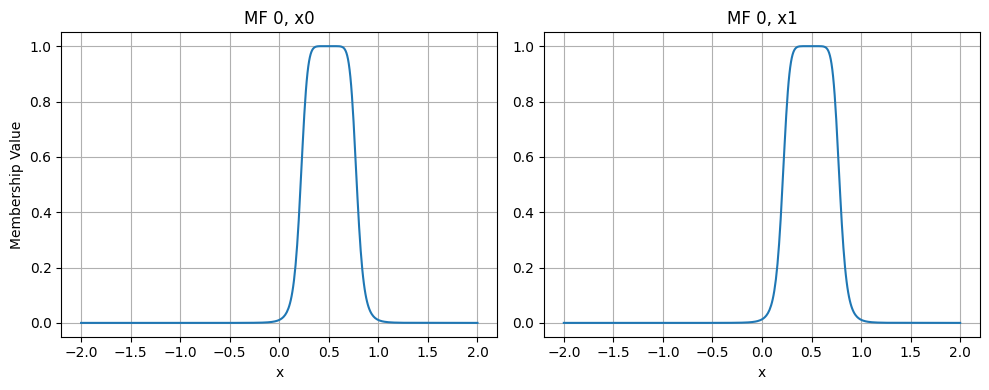

In [25]:
model.plot_premises()

### Hybrid Learning Algorithm

In [26]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [27]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [28]:
Ngrow = 40
dGrow = 0.8
Nsplit = 20
eSplit = 0.5
Nvanish = 6
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=8)
last_training_iteration = True

In [29]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [30]:
%time sonfis(model, train_loader, verbose=True)

Iteration:  0/40 - loss: 4.309961 - validation loss: 4.922593
 -> ANFIS rules: 1

Iteration:  1/40 - loss: 3.596117 - validation loss: 4.533282
 -> ANFIS rules: 2

Iteration:  2/40 - loss: 3.690944 - validation loss: 4.702654
 -> ANFIS rules: 4

Iteration:  3/40 - loss: 3.115542 - validation loss: 3.810912
 -> ANFIS rules: 6

Iteration:  4/40 - loss: 3.622020 - validation loss: 3.873046
 -> ANFIS rules: 9

Iteration:  5/40 - loss: 3.463548 - validation loss: 3.690883
 -> ANFIS rules: 11

Iteration:  6/40 - loss: 0.330702 - validation loss: 0.332926
 -> ANFIS rules: 19

Iteration:  7/40 - loss: 0.243578 - validation loss: 0.348814
 -> ANFIS rules: 22

Iteration:  8/40 - loss: 0.222943 - validation loss: 0.282782
 -> ANFIS rules: 24

Iteration:  9/40 - loss: 0.378153 - validation loss: 0.499988
 -> ANFIS rules: 27

Iteration: 10/40 - loss: 0.380119 - validation loss: 0.386834
 -> ANFIS rules: 29

Iteration: 11/40 - loss: 0.520594 - validation loss: 0.608646
 -> ANFIS rules: 31

Iteration

In [31]:
test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.06994348212512626
RMSE: 0.2644683007944927
MAE: 0.18276950758650712
R2: 0.9806239734804244
MAPE: 54.80663264756943


In [32]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.06034129523961876
RMSE: 0.2456446523733394
MAE: 0.17866070802783146
R2: 0.9829390023956943
MAPE: 1.9986102216481427


# Synt 1

## Data

In [33]:
def f(x0, x1, x2):
    return (1 + x0**0.5 + x1 + x2**-1.5)

#Training
x0 = np.random.uniform(1,6,216)
x1 = np.random.uniform(1,6,216)
x2 = np.random.uniform(1,6,216)

Y = f(x0, x1, x2)


#Testing
x0_test = np.random.uniform(1.5,5.5,125)
x1_test = np.random.uniform(1.5,5.5,125)
x2_test = np.random.uniform(1.5,5.5,125)

Y_test = f(x0_test, x1_test, x2_test)

In [34]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0, x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [35]:
loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [36]:
model = h_ANFIS(
    input_size = 3,
    num_mfs = 1,
    outputs = 1,
    rule_reduced=True
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [37]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}

early_stopping = EarlyStopping(patience=10, delta=0.01)

In [38]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [39]:
Ngrow = 30
dGrow = 0.8
Nsplit = 40
eSplit = 0.5
Nvanish = 30
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [40]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [41]:
%time sonfis(model, loader, verbose=True)

Iteration:  0/40 - loss: 42.809826 - validation loss: 40.706822
 -> ANFIS rules: 1

Iteration:  1/40 - loss: 0.084646 - validation loss: 0.109184
 -> ANFIS rules: 2

Iteration:  2/40 - loss: 0.117676 - validation loss: 0.108150
 -> ANFIS rules: 3

Iteration:  3/40 - loss: 0.080018 - validation loss: 0.081810
 -> ANFIS rules: 3

Iteration:  4/40 - loss: 0.069429 - validation loss: 0.052237
 -> ANFIS rules: 5

No more updates
Iteration:  5/40 - loss: 0.069429 - validation loss: 0.052237
 -> ANFIS rules: 5

Last training iteration
Iteration:  6/40 - loss: 0.012313 - validation loss: 0.010177

Training finished
 -> ANFIS rules: 5

CPU times: user 4.39 s, sys: 10.6 ms, total: 4.4 s
Wall time: 954 ms


In [42]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.00782442346694935
RMSE: 0.08845577124726996
MAE: 0.06946997641124578
R2: 0.9937983636585136
MAPE: 0.01061801760690355


In [43]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.011877483240340084
RMSE: 0.1089838668810209
MAE: 0.08291518016340972
R2: 0.9942658326882423
MAPE: 0.013018709917759046


# Synt 2

## Data

In [44]:
def f(x1, x2):
    return ((np.sin(x1)*np.sin(x2))/(x1*x2))

#Training
x1 = np.random.uniform(-5,5,196)
x2 = np.random.uniform(-5,5,196)

#noise and outliers
epsilon = 0.5

G = np.random.normal(0, 0.01, 196)
H = np.random.normal(0, 0.05, 196)
F = G * (1 - epsilon) + epsilon * H

Y = f(x1, x2) + F


#Testing
x1_test = np.random.uniform(-5,5,392)
x2_test = np.random.uniform(-5,5,392)

Y_test = f(x1_test, x2_test)

In [45]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [46]:
loader = data.DataLoader(
    data.TensorDataset(
        torch.from_numpy(scaled_train), 
        torch.from_numpy(Y)), 
    batch_size = 4, 
    shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

In [47]:
x_train.shape

torch.Size([196, 2])

## Model & Training

### ANFIS

In [48]:
model = h_ANFIS(
    input_size = 2,
    num_mfs = 1,
    outputs = 1,
    rule_reduced=True,
    membership_function=Gaussian_MF
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [49]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.01, 'weight_decay': 0.1}

early_stopping = EarlyStopping(patience=10, delta=0.01)

In [50]:
trainer = Hybrid_learning_algorithm(
    epochs=40,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [51]:
Ngrow = 20
dGrow = 0.8
Nsplit = 30
eSplit = 0.7
Nvanish = 20
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
#sonfis_early_stopping = EarlyStopping(patience=15, delta=0.01)
sonfis_early_stopping = None
last_training_iteration = True

In [52]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [53]:
%time sonfis(model, loader, verbose=True)

Iteration:  0/40 - loss: 0.565370 - validation loss: 0.443962
 -> ANFIS rules: 1

Iteration:  1/40 - loss: 0.056442 - validation loss: 0.073072
 -> ANFIS rules: 2

Iteration:  2/40 - loss: 0.118104 - validation loss: 0.137393
 -> ANFIS rules: 3

Iteration:  3/40 - loss: 0.322417 - validation loss: 0.251481
 -> ANFIS rules: 2

Iteration:  4/40 - loss: 0.765732 - validation loss: 0.857457
 -> ANFIS rules: 3

Iteration:  5/40 - loss: 0.644162 - validation loss: 0.739855
 -> ANFIS rules: 4

Iteration:  6/40 - loss: 1.071844 - validation loss: 1.122154
 -> ANFIS rules: 5

Iteration:  7/40 - loss: 8.390978 - validation loss: 8.771898
 -> ANFIS rules: 6

Iteration:  8/40 - loss: 11.489603 - validation loss: 12.936879
 -> ANFIS rules: 6

Iteration:  9/40 - loss: 1.279662 - validation loss: 1.909731
 -> ANFIS rules: 6

Iteration: 10/40 - loss: 26.811346 - validation loss: 40.601195
 -> ANFIS rules: 7

Iteration: 11/40 - loss: 7.768759 - validation loss: 9.243665
 -> ANFIS rules: 8

Iteration: 1

In [54]:
model.num_mfs

11

In [55]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.0027344476024085884
RMSE: 0.05229194586557846
MAE: 0.03234129229749022
R2: 0.9649738572640563
MAPE: 3.3145198536388594


In [56]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.0015861405398039797
RMSE: 0.039826379948521305
MAE: 0.027473625748048024
R2: 0.9840887431266534
MAPE: 1.700763547159726


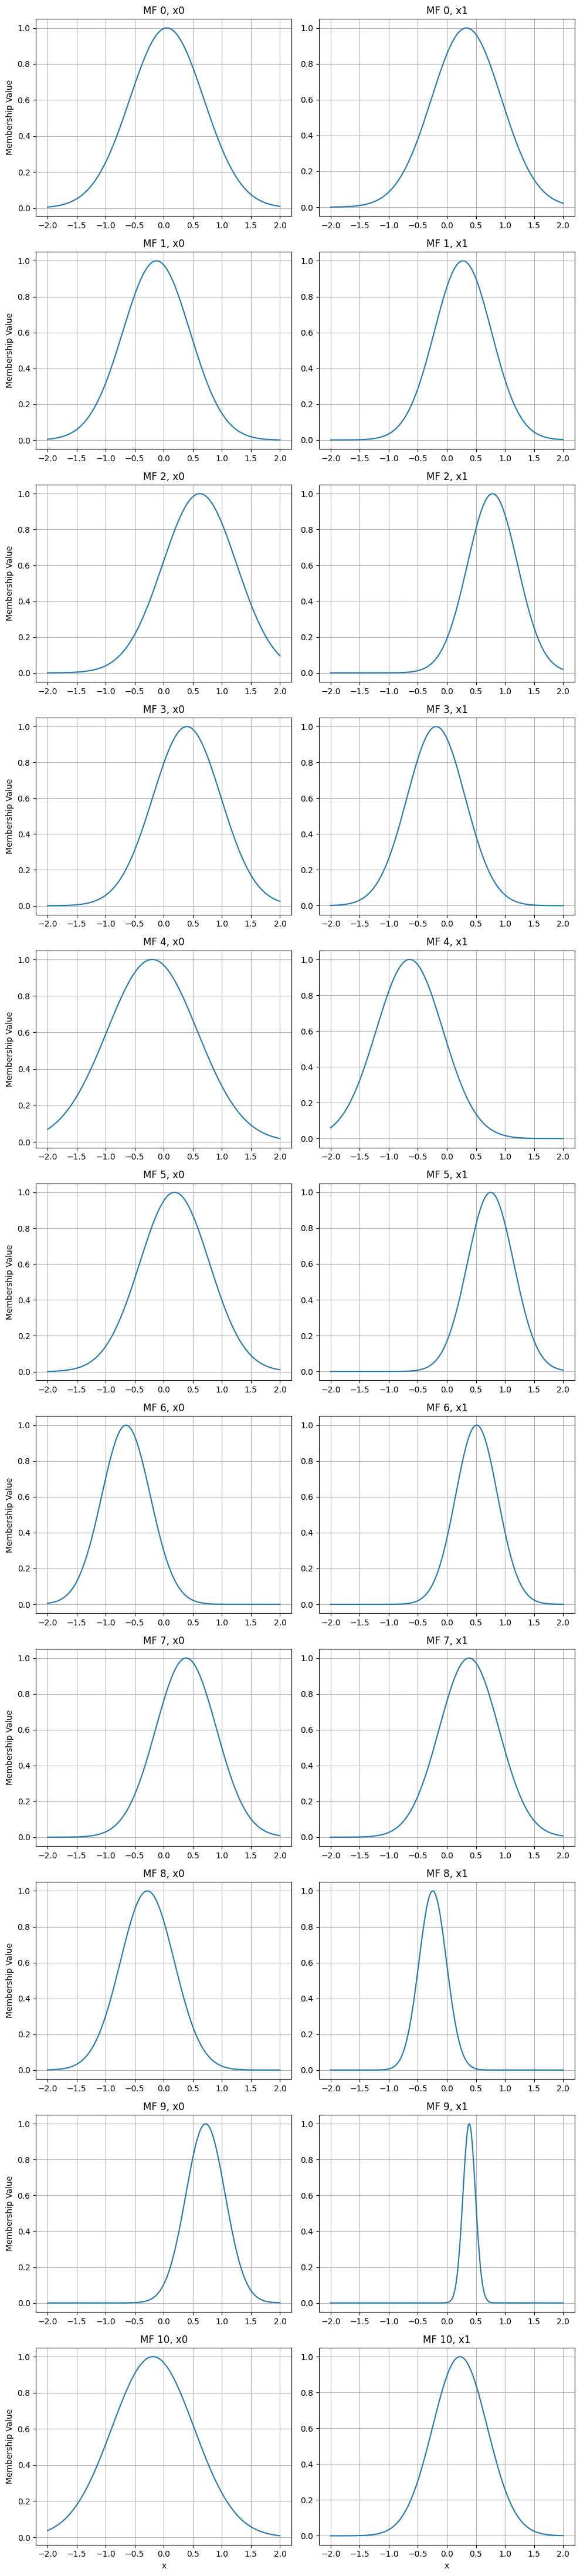

In [57]:
model.plot_premises()

In [58]:
model.consequents_structure

[           c0 (x0)    c1 (x1)          c2
 rule 1   -5.375439 -56.998808  125.736838
 rule 2   60.639616  50.224660  -75.591228
 rule 3  -39.970451  -4.059979   62.790460
 rule 4   20.103812 -48.206607  -75.649021
 rule 5   -6.764343 -11.037917  -22.315101
 rule 6   28.144567  -0.487032  -32.499894
 rule 7   -3.875626   8.284676    0.277806
 rule 8   -0.130792 -53.778205  -49.229200
 rule 9    4.101035   2.186933    2.052116
 rule 10  -0.979380   2.647375   -0.077971
 rule 11  20.486635 -33.308837   62.600291]